# Bearing Anomaly Detection using NASA IMS Dataset

## Objective
To detect early-stage bearing anomalies using unsupervised machine learning and deep learning models on vibration data.

### Dataset Loading

In [153]:
import os
import pandas as pd
import numpy as np

data_dir = r"C:\Projects\BTP_Predictive_Maintenance\data\archive (3)\2nd_test\2nd_test"

data_frames = []

for filename in sorted(os.listdir(data_dir)):
    dataset = pd.read_csv(os.path.join(data_dir, filename), sep='\t', header=None)
    dataset_mean_abs = dataset.abs().mean().values #Feature extraction: Mean Absolute Value (MAV)
    df = pd.DataFrame(dataset_mean_abs.reshape(1, 4),
                      index=[filename],
                      columns=['Bearing 1', 'Bearing 2', 'Bearing 3', 'Bearing 4'])
    data_frames.append(df)

merged_data = pd.concat(data_frames)

### Index Transformation

In [155]:
# transform index to datetime format
merged_data.index = pd.to_datetime(merged_data.index, format='%Y.%m.%d.%H.%M.%S')

merged_data = merged_data.sort_index()
#merged_data.to_csv('merged_Dataset_BearingTest_2.csv')


In [156]:
merged_data.sample(10)

,Bearing 1,Bearing 2,Bearing 3,Bearing 4
2004-02-15 04:42:39,0.061671,0.073925,0.076621,0.043784
2004-02-15 23:22:39,0.061560,0.074548,0.076465,0.044014
2004-02-12 17:52:39,0.061382,0.076712,0.081844,0.043970
2004-02-16 01:32:39,0.061567,0.073101,0.076761,0.044151
2004-02-16 11:32:39,0.070353,0.073257,0.075813,0.044369
2004-02-16 10:22:39,0.069951,0.075315,0.079478,0.044388
2004-02-13 20:52:39,0.059738,0.074568,0.077853,0.043918
2004-02-18 16:52:39,0.099352,0.090289,0.092098,0.054915
2004-02-18 16:22:39,0.093138,0.088552,0.090855,0.053910
2004-02-18 14:42:39,0.116933,0.086316,0.088652,0.056617


## Feature Engineering
Statistical and normalized features are extracted to support anomaly detection models.

In [4]:
#Statistical features for each bearings
'''
Findings: The high skew & kurtosis values of both bearings 1 & 4 indicates that there might be some anomalies in those
bearings a and we should pay close attention to those while analysing further
'''

def extract_statistical_features(df):
    features = pd.DataFrame()
    features['mean'] = merged_data.mean(axis=0)
    features['std'] = merged_data.std(axis=0)
    features['skew'] = merged_data.skew(axis=0)
    features['kurtosis'] = merged_data.kurtosis(axis=0)
    features['max'] = merged_data.max(axis=0)
    features['min'] = merged_data.min(axis=0)
    features['range'] = features['max'] - features['min']
    return features

stat_features = pd.DataFrame(extract_statistical_features(merged_data))
#print(stat_features)
stat_features

,mean,std,skew,kurtosis,max,min,range
Bearing 1,0.080905,0.040171,4.187848,24.726709,0.453318,0.001168,0.452149
Bearing 2,0.078532,0.011779,3.106748,19.736561,0.161011,0.000767,0.160244
Bearing 3,0.081356,0.011596,2.484602,15.261470,0.151296,0.000716,0.150579
Bearing 4,0.047822,0.009541,3.729213,20.337947,0.119042,0.001699,0.117344


### Data Normalization

In [157]:
# Z-score normalization
merged_data_normalized = merged_data.apply(lambda x: (x - x.mean()) / x.std())

In [158]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(merged_data)

# Anomaly Detection Model


### Prepare Data for Temporal Models (LSTM)
Static models detect anomalies at individual timestamps, whereas the LSTM Autoencoder captures temporal degradation patterns, leading to more stable and meaningful anomaly detection.

In [159]:
def create_sequences(data, window_size=20):
    sequences = []
    for i in range(len(data) - window_size):
        seq = data.iloc[i:i+window_size].values
        sequences.append(seq)
    return np.array(sequences)

X_seq = create_sequences(merged_data_normalized, window_size=20)

X_seq.shape

(964, 20, 4)

In [160]:
train_size = int(0.7 * len(X_seq))
X_train = X_seq[:train_size]
X_test  = X_seq[train_size:]


## LSTM Auto-Encoder - Model

In [161]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense

timesteps = X_train.shape[1]
features = X_train.shape[2]

inputs = Input(shape=(timesteps, features))

encoded = LSTM(64, activation='tanh', return_sequences=False)(inputs)
encoded = RepeatVector(timesteps)(encoded)

decoded = LSTM(64, activation='tanh', return_sequences=True)(encoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 20, 4)]           0         
                                                                 
 lstm_2 (LSTM)               (None, 64)                17664     
                                                                 
 repeat_vector_1 (RepeatVect  (None, 20, 64)           0         
 or)                                                             
                                                                 
 lstm_3 (LSTM)               (None, 20, 64)            33024     
                                                                 
 time_distributed_1 (TimeDis  (None, 20, 4)            260       
 tributed)                                                       
                                                                 
Total params: 50,948
Trainable params: 50,948
Non-trainable

### Model Training

In [162]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/30
19/19 [==============================] - 8s 104ms/step - loss: 0.0325 - val_loss: 0.0258
Epoch 2/30
19/19 [==============================] - 1s 28ms/step - loss: 0.0256 - val_loss: 0.0258
Epoch 3/30
19/19 [==============================] - 1s 28ms/step - loss: 0.0164 - val_loss: 0.0190
Epoch 4/30
19/19 [==============================] - 0s 24ms/step - loss: 0.0127 - val_loss: 0.0115
Epoch 5/30
19/19 [==============================] - 0s 24ms/step - loss: 0.0109 - val_loss: 0.0095
Epoch 6/30
19/19 [==============================] - 0s 26ms/step - loss: 0.0088 - val_loss: 0.0094
Epoch 7/30
19/19 [==============================] - 0s 25ms/step - loss: 0.0073 - val_loss: 0.0066
Epoch 8/30
19/19 [==============================] - 1s 27ms/step - loss: 0.0076 - val_loss: 0.0065
Epoch 9/30
19/19 [==============================] - 1s 27ms/step - loss: 0.0071 - val_loss: 0.0062
Epoch 10/30
19/19 [==============================] - 0s 24ms/step - loss: 0.0076 - val_loss: 0.0096
Epoch 11

In [163]:
X_pred = autoencoder.predict(X_test)

reconstruction_error = np.mean(
    np.square(X_test - X_pred), axis=(1,2)
)

reconstruction_error

10/10 [==============================] - 1s 9ms/step


array([6.48849481e-03, 6.14155178e-03, 6.57296502e-03, 5.99971631e-03,
       6.31597617e-03, 6.34119139e-03, 6.13671111e-03, 7.05996793e-03,
       7.53893221e-03, 2.42800491e-02, 4.68533440e-02, 6.84565024e-02,
       8.58824351e-02, 1.00409998e-01, 1.10628761e-01, 1.18838460e-01,
       1.16980790e-01, 1.18927525e-01, 1.15282630e-01, 1.07299472e-01,
       1.00800563e-01, 9.19720825e-02, 8.17415395e-02, 7.15525217e-02,
       6.19344503e-02, 5.34666871e-02, 5.08418926e-02, 5.23817351e-02,
       5.88800477e-02, 6.16113718e-02, 6.05623922e-02, 5.87659321e-02,
       5.76640543e-02, 5.85586337e-02, 5.72093004e-02, 5.87021619e-02,
       6.22079163e-02, 6.14867520e-02, 5.87208147e-02, 5.80209664e-02,
       5.69170877e-02, 5.48581603e-02, 5.16826609e-02, 5.18769080e-02,
       5.17266720e-02, 5.25089002e-02, 5.48029111e-02, 5.40342014e-02,
       5.45209075e-02, 5.50803169e-02, 5.48717365e-02, 5.49626594e-02,
       5.34098697e-02, 5.09511849e-02, 4.84701142e-02, 4.60898334e-02,
      

In [164]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
lstm_ae_scores_norm = scaler.fit_transform(reconstruction_error.reshape(-1,1)).ravel()


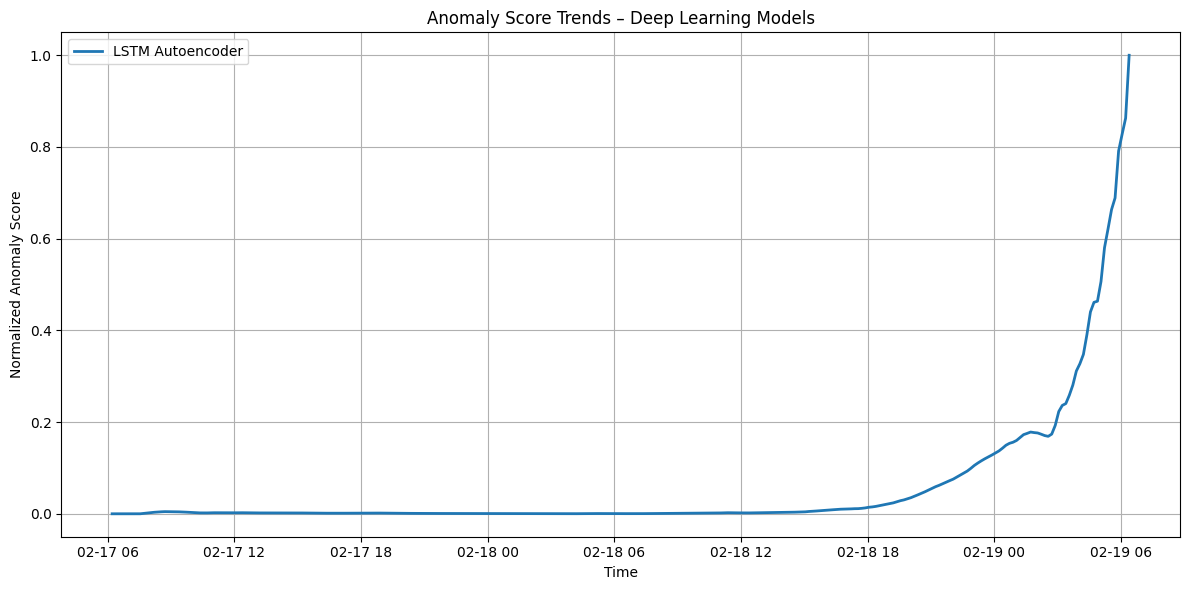

In [165]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

idx_lstm = merged_data.index[-len(lstm_ae_scores_norm):]
plt.plot(idx_lstm, lstm_ae_scores_norm, label='LSTM Autoencoder', linewidth=2)

plt.xlabel("Time")
plt.ylabel("Normalized Anomaly Score")
plt.title("Anomaly Score Trends – Deep Learning Models")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
import numpy as np

def compute_ttf_and_early_detection(
    scores,
    threshold_percentile=90,
    sustain_points=5,
    early_offset=20
):
    scores = np.asarray(scores)

    # Threshold
    threshold = np.percentile(scores, threshold_percentile)

    # Points exceeding threshold
    exceed_idx = np.where(scores >= threshold)[0]

    if len(exceed_idx) == 0:
        return None, None, None, threshold

    # Sustained failure detection
    failure_index = None
    for i in exceed_idx:
        if i + sustain_points < len(scores):
            if np.all(scores[i:i+sustain_points] >= threshold):
                failure_index = i
                break

    if failure_index is None:
        failure_index = exceed_idx[0]

    # Early detection
    early_index = max(0, failure_index - early_offset)

    # Time to Failure
    ttf = len(scores) - failure_index

    return ttf, failure_index, early_index, threshold


### Dynamic Threshold

In [166]:
import numpy as np

def dynamic_threshold(scores, window_size=50, percentile=90):

    thresholds = []

    for i in range(len(scores)):
        
        if i < window_size:
            thresholds.append(None)
            continue

        window = scores[i-window_size:i]

        threshold = np.percentile(window, percentile)

        thresholds.append(threshold)

    return np.array(thresholds)

In [169]:
scores = reconstruction_error

thresholds = dynamic_threshold(scores, window_size=50, percentile=90)

anomalies = scores > thresholds(t)

NameError: name 't' is not defined

In [22]:
results = []

ttf, failure_idx, early_idx, threshold = compute_ttf_and_early_detection(lstm_ae_scores_norm)

results.append({
    "Model": "LSTM Autoencoder",
    "Failure Threshold": threshold,
    "Failure_Index": failure_idx,
    "Early_Detection_Index": early_idx,
    "Time to Failure (TTF)": ttf
})

ttf_df = pd.DataFrame(results)
ttf_df

,Model,Failure Threshold,Failure_Index,Early_Detection_Index,Time to Failure (TTF)
0,LSTM Autoencoder,0.18407,258,238,32


In [23]:
import matplotlib.pyplot as plt

def plot_ttf(scores, model_name, threshold, failure_idx, early_idx):
    plt.figure(figsize=(12,5))
    plt.plot(scores, label="Anomaly Score")
    plt.axhline(threshold, linestyle="--", label="Failure Threshold")
    plt.axvline(early_idx, color="green", linestyle="--", label="Early Detection")
    plt.axvline(failure_idx, color="red", linestyle="--", label="Failure Point")
    plt.title(f"{model_name} – Early Detection & Failure")
    plt.xlabel("Time")
    plt.ylabel("Normalized Anomaly Score")
    plt.legend()
    plt.grid(True)
    plt.show()


In [138]:
# Final fixed decision parameters for deployment
FINAL_THRESHOLD_PERCENTILE = 150
FINAL_SUSTAIN_POINTS = 5
EARLY_WARNING_GAP = 20


In [139]:
def compute_ttf_and_early_detection(
    scores,
    threshold_percentile=90,
    sustain_points=5
):
    scores = np.asarray(scores)
    
    threshold = np.percentile(scores, threshold_percentile)
    exceed_idx = np.where(scores >= threshold)[0]

    if len(exceed_idx) == 0:
        return None, None, None

    for i in exceed_idx:
        if i + sustain_points < len(scores):
            if np.all(scores[i:i+sustain_points] >= threshold):
                failure_index = i
                break
    else:
        failure_index = exceed_idx[0]

    early_index = max(0, failure_index - 20)
    ttf = len(scores) - failure_index

    return ttf, early_index, threshold


In [140]:
def plot_early_detection(scores, threshold, failure_idx, early_idx):
    plt.figure(figsize=(12,5))
    plt.plot(scores, label="Anomaly Score")
    plt.axhline(threshold, color="red", linestyle="--", label="Failure Threshold")
    plt.axvline(early_idx, color="green", linestyle="--", label="Early Detection")
    plt.axvline(failure_idx, color="black", linestyle="--", label="Failure Point")
    plt.title("LSTM Auto-Encoder– Early Detection Validation")
    plt.xlabel("Time")
    plt.ylabel("Normalized Anomaly Score")
    plt.legend()
    plt.grid(True)
    plt.show()


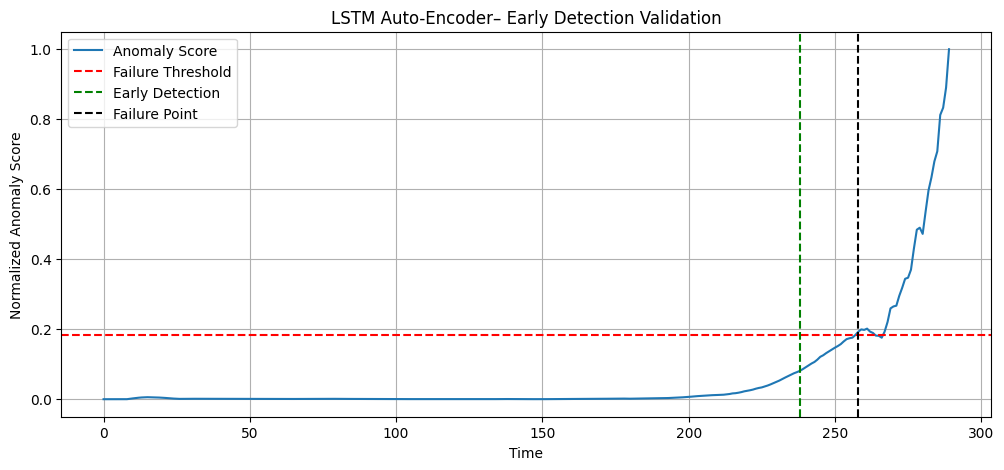

In [141]:
ttf, early_idx, threshold = compute_ttf_and_early_detection(lstm_ae_scores_norm)
failure_idx = len(lstm_ae_scores_norm) - ttf
plot_early_detection(lstm_ae_scores_norm, threshold, failure_idx, early_idx)

In [142]:
#Synthetic Fault Injection - Synthetic Fault Injection
synthetic_scores = lstm_ae_scores_norm.copy()
synthetic_scores[-100:] += np.linspace(0, 1, 100)

ttf, early_idx, _ = compute_ttf_and_early_detection(synthetic_scores)


## Final Predictive Maintenance Output

The developed system continuously monitors bearing vibration signals and generates anomaly scores in real time.
A sustained rise in anomaly score beyond a predefined threshold is interpreted as an indication of impending failure.

### System Capabilities:
- Detects abnormal degradation patterns without labeled data
- Provides early warning before failure
- Estimates Time-to-Failure (TTF) for maintenance planning
- Supports condition-based maintenance decisions

This end-to-end pipeline can be directly deployed in real industrial environments
for proactive fault prevention and maintenance scheduling.


# Decision Layer / Maintenance Intelligence Layer.

In [143]:
def maintenance_decision(
    score,
    threshold,
    early_idx,
    failure_idx,
    current_idx,
    ttf
):
    if current_idx < early_idx:
        status = "Normal"
        reason = "System operating within normal behavior"
        action = "Continue routine monitoring"
        
    elif early_idx <= current_idx < failure_idx:
        status = "Warning"
        reason = "Anomaly trend increasing toward failure"
        action = "Schedule inspection and prepare maintenance"
        
    else:
        status = "Critical"
        reason = "Failure likely imminent based on anomaly threshold"
        action = "Immediate shutdown or corrective maintenance"
    
    return {
        "Status": status,
        "Reason": reason,
        "Lead Time (TTF)": ttf,
        "Recommended Action": action
    }


In [144]:
model = autoencoder
scores = lstm_ae_scores_norm

ttf, early_idx, threshold = compute_ttf_and_early_detection(scores)
failure_idx = len(scores) - ttf

current_idx = len(scores) - 500      # simulate checking system earlier
# current_idx = len(scores) - x : x = 1 -> Latest state(Failure state) ,
#x = len(scores) -> Beginning of Data, x = 10 ->10 time steps before now


current_score = scores[current_idx]

ttf = max(failure_idx - current_idx, 0)

decision_dict = maintenance_decision(
    current_score,
    threshold,
    early_idx,
    failure_idx,
    current_idx,
    ttf
)

decision = pd.DataFrame([decision_dict])
decision
decision_vertical = pd.DataFrame(decision_dict.items(), columns=["Field", "Value"])
decision_vertical



,Field,Value
0,Status,Normal
1,Reason,System operating within normal behavior
2,Lead Time (TTF),468
3,Recommended Action,Continue routine monitoring


### Final Expected output - 
- Status: WARNING
- Reason: Sustained anomaly detected
- Lead time before failure: ~120 cycles
- Recommended action: Schedule inspection


# Real-Time System Validation Using Synthetic Data
- Synthetic data used only for testing
- Models trained on real data
- Demonstrates deployment readiness

In [145]:
import numpy as np

def synthetic_stream(
    n_points=2000,
    n_features=4,
    anomaly_start=1200,
    failure_start=1600,
    noise_level=0.05
):
    """
    Yields one data point at a time (real-time simulation)
    """
    for i in range(n_points):
        if i < anomaly_start:
            point = np.random.normal(0, noise_level, n_features)
        elif i < failure_start:
            point = np.random.normal(0.5, noise_level * 2, n_features)
        else:
            point = np.random.normal(1.2, noise_level * 3, n_features)
        yield point


In [146]:
def lstm_ae_scoring_function(window, model):
    """
    window shape: (1, 20, num_features)
    """
    reconstructed = model.predict(window, verbose=0)
    error = np.mean(np.square(window - reconstructed))
    return error


In [147]:
#New Updated
import numpy as np

class RealTimeEvaluator:
    def __init__(self, model, threshold, window_size):
        self.model = model
        self.threshold = threshold
        self.window_size = window_size
        self.buffer = []

    def _estimate_lead_time(self, score):
        """
        Simple heuristic:
        Higher anomaly score → shorter lead time
        """
        if score < self.threshold:
            return "N/A"
        elif score < self.threshold * 1.2:
            return "10–15 min"
        elif score < self.threshold * 1.5:
            return "5–10 min"
        else:
            return "< 5 min"

    def _recommended_action(self, status):
        if status == "Normal":
            return "Continue normal operation"
        elif status == "Warning":
            return "Inspect system, schedule maintenance"
        else:
            return "Immediate shutdown and repair"

    def update(self, new_point):
        self.buffer.append(new_point)

        # Maintain sliding window
        if len(self.buffer) < self.window_size:
            return None
        if len(self.buffer) > self.window_size:
            self.buffer.pop(0)

        window = np.array(self.buffer).reshape(1, self.window_size, -1)

        # Reconstruction
        recon = self.model.predict(window, verbose=0)

        # Anomaly score
        score = np.mean(np.square(window - recon))

        # Decision logic
        if score < self.threshold:
            status = "Normal"
            reason = "Reconstruction error within normal range"
        elif score < self.threshold * 1.3:
            status = "Warning"
            reason = "Deviation detected from learned healthy pattern"
        else:
            status = "Failure"
            reason = "Severe deviation indicating imminent fault"

        return {
            "Status": status,
            "Reason": reason,
            "Lead Time": self._estimate_lead_time(score),
            "Recommended Action": self._recommended_action(status),
            "Anomaly Score": score
        }

In [148]:
train_recon = autoencoder.predict(X_train, verbose=0)
train_errors = np.mean(np.square(X_train - train_recon), axis=(1, 2))

threshold = np.percentile(train_errors, 95)
print("Threshold:", threshold)


Threshold: 0.008356478122043388


In [149]:
import pandas as pd

stream = synthetic_stream()

evaluator = RealTimeEvaluator(
    model=autoencoder,
    threshold=threshold,
    window_size=20
)

logs = []

'''
import time

for point in stream:
    res = evaluator.update(point)
    if res is not None:
        print(res)
    time.sleep(0.05)  # simulate sensor delay

#df = pd.DataFrame(logs)
#df.head()

logs '''

import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

scores = []

for point in stream:
    res = evaluator.update(point)
    if res is not None:
        scores.append(res["Anomaly Score"])

        clear_output(wait=True)
        plt.figure(figsize=(10,3))
        plt.plot(scores)
        plt.axhline(threshold, color='r', linestyle='--')
        plt.title("Live Anomaly Score")
        plt.show()

    time.sleep(0.05)


KeyboardInterrupt: 

In [ ]:
import numpy as np

train_errors = np.mean(np.square(X_train - train_recon), axis=(1, 2))

mean_train_error = np.mean(train_errors)
std_train_error = np.std(train_errors)

In [ ]:
##Trigger Warning Funct
import datetime

# Thresholds (example values – replace with yours)
T_WARNING = mean_train_error + 2 * std_train_error
T_CRITICAL = mean_train_error + 3 * std_train_error
N_CONSECUTIVE = 3

warning_counter = 0
critical_counter = 0


def evaluate_score(score):
    global warning_counter, critical_counter
    
    if score >= T_CRITICAL:
        critical_counter += 1
        warning_counter = 0
        
        if critical_counter >= N_CONSECUTIVE:
            log_event(score, "CRITICAL")
            return "CRITICAL"
    
    elif score >= T_WARNING:
        warning_counter += 1
        critical_counter = 0
        
        if warning_counter >= N_CONSECUTIVE:
            log_event(score, "WARNING")
            return "WARNING"
    
    else:
        warning_counter = 0
        critical_counter = 0
    
    return "NORMAL"


def log_event(score, status):
    timestamp = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    log_message = f"""
    [{timestamp}]
    Asset: Fan-01
    Score: {score:.6f}
    Status: {status}
    """
    
    print(log_message)
    
    with open("maintenance_logs.txt", "a") as f:
        f.write(log_message + "\n")

### Real Time Evaluation of Synthetic data

In [151]:
## Real Time Evaluation - OUTPUT

from IPython.display import clear_output, display
import time
import pandas as pd

logs = []

for point in stream:
    res = evaluator.update(point)
    if res is not None:
        logs.append(res)

        clear_output(wait=True)
        display(pd.DataFrame(logs))  # show last 10 rows

    time.sleep(0.05)



,Status,Reason,Lead Time,Recommended Action,Anomaly Score
0,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.014701
1,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.014581
2,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.013567
3,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.013713
4,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.013266
5,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.014447
6,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.014030
7,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.013686
8,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.013482
9,Failure,Severe deviation indicating imminent fault,< 5 min,Immediate shutdown and repair,0.014806


KeyboardInterrupt: 

In [ ]:
## Real Time Evaluation - ANOMALY SCORE PLOT

from IPython.display import clear_output, display
import time
import pandas as pd
'''
logs = []

for point in stream:
    res = evaluator.update(point)
    if res is not None:
        logs.append(res)

        clear_output(wait=True)
        display(pd.DataFrame(logs))  # show last 10 rows

    time.sleep(0.05)

'''
scores = []


for point in stream:
    res = evaluator.update(point)
    if res is not None:
        scores.append(res["Anomaly Score"])

        clear_output(wait=True)
        plt.figure(figsize=(10,3))
        plt.plot(scores)
        plt.axhline(threshold, color='r', linestyle='--')
        plt.title("Live Anomaly Score")
        plt.show()

    time.sleep(0.05)
    

In [ ]:
def run_realtime_monitor(stream, evaluator, threshold):
    scores = []
    logs = []

    for point in stream:
        result = evaluator.update(point)

        if result is not None:
            score = result["Anomaly Score"]
            scores.append(score)
            logs.append(result)

            clear_output(wait=True)

            # ----- Plot -----
            plt.figure(figsize=(10,3))
            plt.plot(scores)
            plt.axhline(threshold, linestyle='--')
            plt.title("Live Anomaly Score")
            plt.xlabel("Time")
            plt.ylabel("Reconstruction Error")
            plt.show()

            # ----- Evaluation Output -----
            print("Latest Evaluation:")
            print(f"Status: {result['Status']}")
            print(f"Reason: {result['Reason']}")
            print(f"Lead Time: {result['Lead Time']}")
            print(f"Action: {result['Recommended Action']}")

        time.sleep(0.05)

In [ ]:
# ------- DONE ----------------

Now we are planning to build a Real-time dashboard (like industrial monitoring software) using Streamlit or Plotly live graphs.

Also We are working on finding some effective ways for selecting thresholds

In [109]:
#evaluator = RealTimeEvaluator(model, threshold, window_size=20)
evaluator = RealTimeEvaluator(
    model= autoencoder,
    threshold=threshold,
    window_size=20
)

Model type inside evaluator: <class 'keras.engine.functional.Functional'>


In [110]:
def dataset_stream(X):
    for i in range(len(X)):
        yield X[i]

In [111]:
#stream = synthetic_stream(X_test)
stream = dataset_stream(X_test)


In [119]:
#run_realtime_monitor(stream, evaluator, threshold)

In [ ]:
print(type(autoencoder))

In [ ]:
print(type(autoencoder))
print(autoencoder)